### Reading the WTL results and generating a interpolation function

In [2]:
import xarray as xr
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Reading the .nc dataset
file = r'202511181802_wtl_vol.nc'
ds = xr.open_dataset(file)

In [9]:
ds.spruce_fraction

<xarray.DataArray 'spruce_fraction' (spruce_fraction: 2)>
array([0.6, 0.8])
Coordinates:
  * spruce_fraction  (spruce_fraction) float64 0.6 0.8

In [10]:
# Generating the interpolation function
# Select the scenario
wtl = ds.sel(forcing_id=1.0, # 1 = ruotsinkyla, 2 = asmonkorpi
           ditch_depth=0.8, 
           ditch_spacing=40., 
           decid_fraction=0.2, 
           pine_fraction=0.0, 
           spruce_fraction=0.8,
           soil_id=1.0)['WTL'].data # 1.0 = spaghnum, 2.0 = carex

vol = ds['vol'].data

# Volume to WTL relationship
vol_to_wtl = interp1d(
    vol,               # x-values
    wtl,               # y-values
    kind='linear',
    fill_value='interpolate'
    )

# WTL to volume relationship
wtl_to_vol = interp1d(
    wtl,               # x-values
    vol,               # y-values
    kind='linear',
    fill_value='interpolate'
    )

In [16]:
# Testing the interpolation function
test_vol = 200
test_wtl = -0.44
print('Volume of', test_vol, 'm3 ha-1 equals WTL of', vol_to_wtl(test_vol), 'm')
print('WTL of', test_wtl, 'm equals volume of', wtl_to_vol(test_wtl), 'm3 ha-1')

Volume of 200 m3 ha-1 equals WTL of -0.4526550769805908 m
WTL of -0.44 m equals volume of 125.25506607573887 m3 ha-1


Text(0.5, 1.0, '')

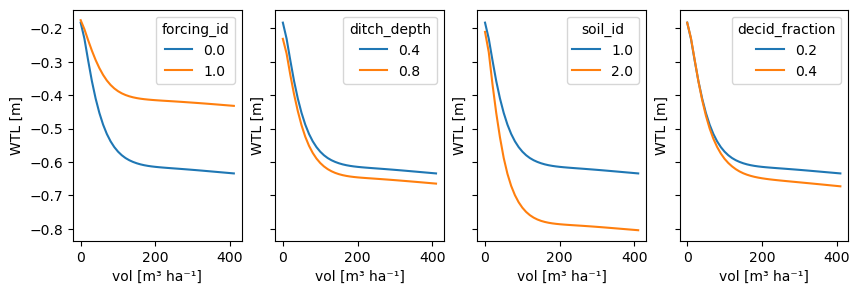

In [21]:
# Example plot
fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharey=True)

# --- 1. Forcing ID ---
ax = axes[0]
forcings = np.array([0.0, 1.0])
for forcing in forcings:
    ds.sel(forcing_id=forcing, 
           ditch_depth=0.4, 
           ditch_spacing=40., 
           decid_fraction=0.2, 
           pine_fraction=0.0, 
           spruce_fraction=0.8, 
           soil_id=1.0)['WTL'].plot(ax=ax, label=f'{forcing}')
ax.set_title("")
ax.legend(title="forcing_id")

# --- 2. Ditch depth ---
ax = axes[1]
ditch_depths = np.array([0.4, 0.8])
for ditch_depth in ditch_depths:
    ds.sel(forcing_id=0.0, 
           ditch_depth=ditch_depth, 
           ditch_spacing=40., 
           decid_fraction=0.2, 
           pine_fraction=0.0, 
           spruce_fraction=0.8, 
           soil_id=1.0)['WTL'].plot(ax=ax, label=f'{ditch_depth}')
ax.legend(title="ditch_depth")
ax.set_title("")

# --- 3. Soil ID ---
ax = axes[2]
soil_ids = np.array([1.0, 2.0])
for soil_id in soil_ids:
    ds.sel(forcing_id=0., 
           ditch_depth=0.4, 
           ditch_spacing=40., 
           decid_fraction=0.2, 
           pine_fraction=0.0, 
           spruce_fraction=0.8, 
           soil_id=soil_id)['WTL'].plot(ax=ax, label=f'{soil_id}')
ax.legend(title="soil_id")
ax.set_title("")

# --- 4. Fractions (decid + spruce) ---
ax = axes[3]
decid_fractions = np.array([0.2, 0.4])
spruce_fractions = np.array([0.8, 0.6])
for decid_fraction, spruce_fraction in zip(decid_fractions, spruce_fractions):
    ds.sel(forcing_id=0., 
           ditch_depth=0.4, 
           ditch_spacing=40., 
           decid_fraction=decid_fraction, 
           pine_fraction=0.0, 
           spruce_fraction=spruce_fraction, 
           soil_id=1.0)['WTL'].plot(ax=ax, 
                                     label=f'{decid_fraction}')
ax.legend(title='decid_fraction')
ax.set_title("")